In [50]:
import pandas as pd #importing pandas library to work with dataframes

## STEP 1: Load Dataset

In [51]:
df = pd.read_csv('/Users/maniyadav/Documents/GitHub/data.csv') #don't write the macintosh hd in path name, just write the path from the folder where your jupyter notebook is present. like this: df = pd.read_csv('data.csv')
print(df)

    Duration          Date  Pulse  Maxpulse  Calories
0         60  '2020/12/01'    110       130     409.1
1         60  '2020/12/02'    117       145     479.0
2         60  '2020/12/03'    103       135     340.0
3         45  '2020/12/04'    109       175     282.4
4         45  '2020/12/05'    117       148     406.0
5         60  '2020/12/06'    102       127     300.0
6         60  '2020/12/07'    110       136     374.0
7        450  '2020/12/08'    104       134     253.3
8         30  '2020/12/09'    109       133     195.1
9         60  '2020/12/10'     98       124     269.0
10        60  '2020/12/11'    103       147     329.3
11        60  '2020/12/12'    100       120     250.7
12        60  '2020/12/12'    100       120     250.7
13        60  '2020/12/13'    106       128     345.3
14        60  '2020/12/14'    104       132     379.3
15        60  '2020/12/15'     98       123     275.0
16        60  '2020/12/16'     98       120     215.2
17        60  '2020/12/17'  

# STEP 2: Inspect the dataset structure

## Shows missing values and datatypes

In [52]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     object 
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.4+ KB


## Look at the first 5 rows to see what the data actually looks like

In [53]:
df.head() #first 5 rows of the dataset

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0


## Total number of rows and columns

In [54]:
df.shape #number of rows and columns in the dataset

(32, 5)

## Statistical summary like Mean, Min, Max, Quartiles

In [55]:
df.describe() #statistical summary of numeric columns

,Duration,Pulse,Maxpulse,Calories
count,32.000000,32.000000,32.000000,30.000000
mean,68.437500,103.500000,128.500000,304.680000
std,70.039591,7.832933,12.998759,66.003779
min,30.000000,90.000000,101.000000,195.100000
25%,60.000000,100.000000,120.000000,250.700000
50%,60.000000,102.500000,127.500000,291.200000
75%,60.000000,106.500000,132.250000,343.975000
max,450.000000,130.000000,175.000000,479.000000


# STEP 3 :Checking for the missing values in the dataset

In [56]:
df.isnull() #false: not null, true: null

,Duration,Date,Pulse,Maxpulse,Calories
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,False,False
6,False,False,False,False,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


In [57]:
df.isnull().sum() #count of null values in each column

Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    2
dtype: int64

## Handling the missing values

In [58]:
df.fillna(value = 0) 

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0
5,60,'2020/12/06',102,127,300.0
6,60,'2020/12/07',110,136,374.0
7,450,'2020/12/08',104,134,253.3
8,30,'2020/12/09',109,133,195.1
9,60,'2020/12/10',98,124,269.0


# STEP 4: Removing duplicates

In [59]:
df.drop_duplicates(inplace = True) #find and delete duplicate rows

# STEP 5: Fixing date types

In [60]:
df['Date'] = pd.to_datetime(df['Date'], format = 'mixed') #convert date column to datetime format

In [61]:
df.dropna(subset = ['Date'], inplace = True) #drop rows where date is null, because we can't convert null to datetime format

In [62]:
print(df.info()) #check if date column is converted to datetime format and if null values are removed

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Duration  30 non-null     int64         
 1   Date      30 non-null     datetime64[ns]
 2   Pulse     30 non-null     int64         
 3   Maxpulse  30 non-null     int64         
 4   Calories  28 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 1.4 KB
None


# STEP 6: Handle missing calorie by replacing it with the column's median value

In [63]:
median_calories = df['Calories']. median() #calculate median of calories column

In [64]:
df['Calories'] = df['Calories'].fillna(median_calories) #Median is simply the exact middle number if you lined up all your calorie numbers from smallest to largest

# STEP 7: Fix the outliner value (Duration = 450)

In [65]:
df.loc[7, 'Duration'] = 45 #loc is short form for location
#using this so that it can change the exact column or row values of the cell

# STEP 8: Remove the duplicate values

In [66]:
df.drop_duplicates(inplace = True)

# STEP 9: Check the clean dataset

In [67]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Duration  30 non-null     int64         
 1   Date      30 non-null     datetime64[ns]
 2   Pulse     30 non-null     int64         
 3   Maxpulse  30 non-null     int64         
 4   Calories  30 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 2.5 KB
None


# STEP 10: All the required charts for the dataset

## Distribution of workout duration (BAR/PIE CHART)

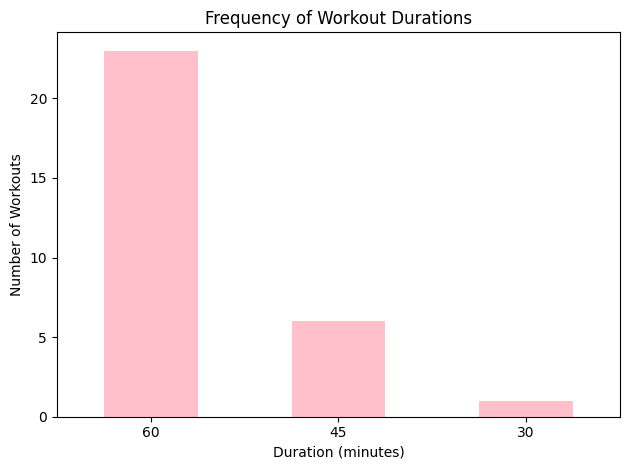

In [68]:
import matplotlib.pyplot as plt

df['Duration'].value_counts().plot(kind='bar', color= 'pink') #count of unique values in duration column
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Workouts')
plt.title('Frequency of Workout Durations')
plt.xticks(rotation=0) #rotate x-axis labels to horizontal
plt.tight_layout()
plt.savefig('duration_frequency.png')
plt.show()
plt.close()

## Relationship between Pulse and Maxpulse (SCATTER PLOT)

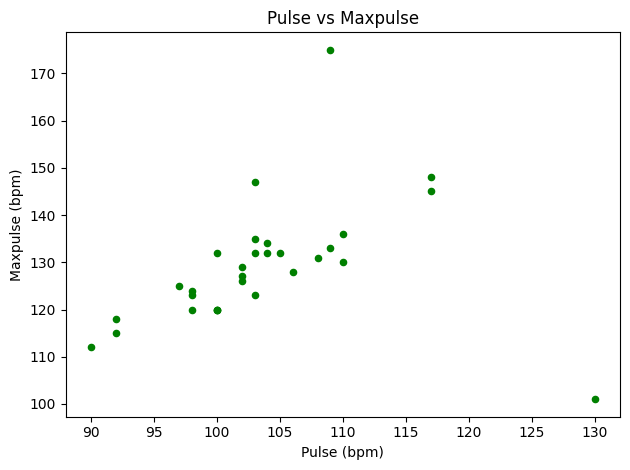

In [71]:
df.plot(x = 'Pulse', y = 'Maxpulse', kind = 'scatter', color = 'green') #scatter plot to see the relationship between pulse and maxpulse
plt.xlabel('Pulse (bpm)')
plt.ylabel('Maxpulse (bpm)')
plt.title('Pulse vs Maxpulse')
plt.tight_layout()
plt.savefig('pulse_relationship.png')
plt.show()
plt.close()

## Calories burned over time (LINE PLOT)

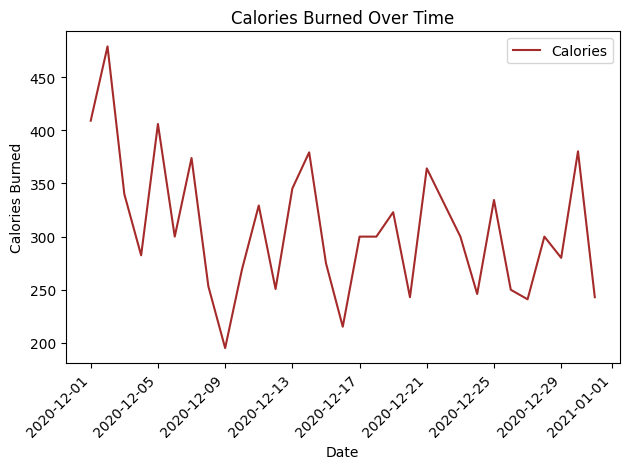

In [72]:
df.plot (kind = 'line', x = 'Date', y = 'Calories', color = 'brown') #line plot to see the trend of calories burned over time
plt.title('Calories Burned Over Time')
plt.xlabel('Date')
plt.ylabel('Calories Burned')
plt.xticks(rotation=45) #rotate x-axis labels to prevent overlap
plt.tight_layout()
plt.savefig('calories_trend.png')
plt.show()
plt.close()

# Conclusion
1. Data cleaning
- Inconsistent Dates: Standardized using pd.to_datetime(format='mixed')
- Missing Data: Dropped 1 row missing a date; filled 2 rows missing calories with the column median ($291.2$)
- Outliers: Corrected a 450-minute workout typo to 45 minutes
- Duplicates: Removed 1 duplicate row, leaving 29 clean, unique rows.

2. Key Insights
- Workout Habit: 60-minute sessions are heavily favored
- Heart Rate: Average pulse and peak pulse (Maxpulse) show a direct positive correlation
- Energy Burn: Calories fluctuated between 200 and 480 kcal per session based on duration and intensity. 